# Conclusion: Best Practices and Future Trends in Options Pricing

## Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

## Setting

In [2]:
# Set a fixed random seed for reproducibility
keras.utils.set_random_seed(42)

## Recap of Key Concepts and Best Practices

In [3]:
# Loading mb_tickerdf12302025 2025-12-30 17-24-53-423976
# Define the file path
file_path = "mb_tickerdf12302025 2025-12-30 17-24-53-423976.csv"

# Load the file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-12-31,130.520487,131.162969,128.223139,129.167389,99116600,0.0,0.0
1,2021-01-04,129.975370,130.062977,123.394829,125.974480,143301900,0.0,0.0
2,2021-01-05,125.468261,128.242606,125.020466,127.531975,97664900,0.0,0.0
3,2021-01-06,124.329352,127.570950,123.024922,123.239082,155088000,0.0,0.0
4,2021-01-07,124.952354,128.135547,124.465627,127.444389,109578200,0.0,0.0


In [4]:
# Get Data
data = df.copy()

# Compute daily returns
data['Returns'] = data['Close'].pct_change()

# Assume an option's delta is 0.5
delta = 0.5

# Calculate required hedge for each day
data['Hedge'] = -delta * data['Returns']

# Compute cumulative returns of the hedge
data['Cumulative Hedge Returns'] = np.cumprod(1 + data['Hedge'].fillna(0))

data[['Close', 'Hedge', 'Cumulative Hedge Returns']]

,Close,Hedge,Cumulative Hedge Returns
0,129.167389,NaN,1.000000
1,125.974480,0.012360,1.012360
2,127.531975,-0.006182,1.006101
3,123.239082,0.016831,1.023035
4,127.444389,-0.017062,1.005580
...,...,...,...
1250,272.359985,-0.002565,0.595768
1251,273.809998,-0.002662,0.594182
1252,273.399994,0.000749,0.594627
1253,273.760010,-0.000658,0.594235


## Machine Learning and AI in Options Valuation

### Predictive analytics

In [5]:
# Using current-day OHLC data to predict the next day's closing price
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# Feature columns: using Open, High, Low, Close as features
features = df[['Open', 'High', 'Low', 'Close']]
target = df['Target']

# Preserve chronological order for time-series prediction
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

Mean Squared Error: 18.7590
Root Mean Squared Error: 4.3312


### Neural Networks for Nonlinear Relationships in Options Pricing

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 137.2480 - val_loss: 75.9179
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 68.5334 - val_loss: 76.3661
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 68.7539 - val_loss: 76.3224
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 68.6352 - val_loss: 76.2536
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 68.4581 - val_loss: 76.0964
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 68.2235 - val_loss: 75.8560
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 67.9412 - val_loss: 75.5412
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 67.6171 - val_loss: 75.1590
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 67.2539 - val_loss: 74.7134
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 66.8516 - val_loss: 74.2047
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 66.4086 - val_loss: 73.6303
Epoch 12/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 

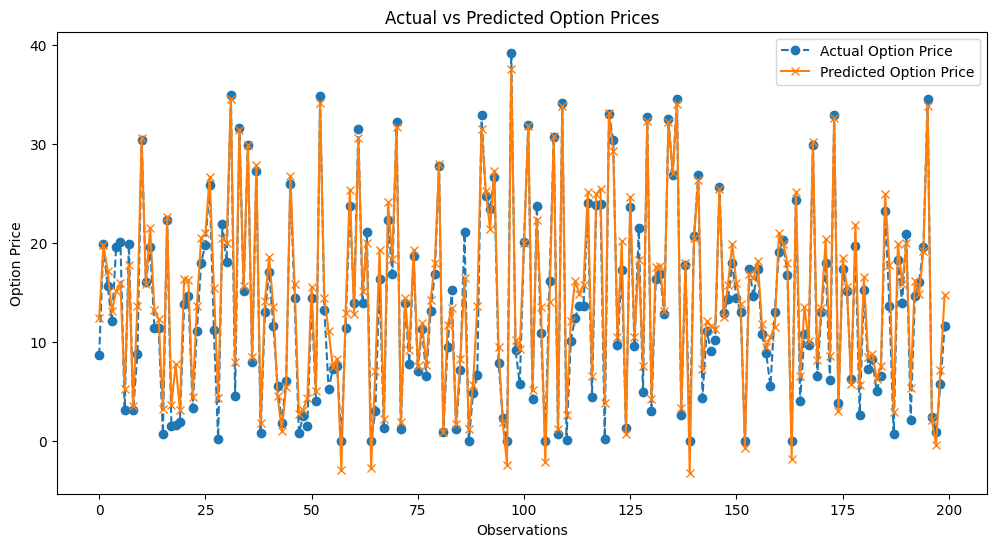

In [6]:
# Set random seed for reproducibility
keras.utils.set_random_seed(42)

# Generate synthetic Black-Scholes call option data
n_samples = 1000

S = np.random.uniform(80, 120, n_samples)
sigma = np.random.uniform(0.10, 0.50, n_samples)
T = np.random.uniform(0.05, 2.0, n_samples)

K = 100.0
r = 0.05

d1 = (
    np.log(S / K)
    + (r + 0.5 * sigma**2) * T
) / (sigma * np.sqrt(T))

d2 = d1 - sigma * np.sqrt(T)

option_prices = (
    S * norm.cdf(d1)
    - K * np.exp(-r * T) * norm.cdf(d2)
)

# Features: [Underlying Price, Volatility, Time to Maturity]
X = np.column_stack((S, sigma, T))
y = option_prices.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Building the Neural Network model
model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compiling the model
model.compile(optimizer='adam', loss='mse')

# Training the model
model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=10,
    validation_split=0.2
)

# Predicting option prices
predictions = model.predict(X_test)

# Plotting the actual vs predicted option prices
plt.figure(figsize=(12, 6))
plt.plot(
    y_test,
    label="Actual Option Price",
    linestyle='--',
    marker='o'
)
plt.plot(
    predictions,
    label="Predicted Option Price",
    linestyle='-',
    marker='x'
)

plt.title("Actual vs Predicted Option Prices")
plt.xlabel("Observations")
plt.ylabel("Option Price")
plt.legend()
plt.show()

### Neural Networks for Time Series Forecasting in Options Pricing

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0064 - val_loss: 9.4796e-04
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.2248e-04 - val_loss: 2.9504e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5915e-04 - val_loss: 2.9427e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3293e-04 - val_loss: 3.1075e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1669e-04 - val_loss: 3.0746e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0325e-04 - val_loss: 2.9371e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9395e-04 - val_loss: 2.8085e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8751e-04 - val_loss: 2.7062e-04
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8239e-04 - val_loss: 2.6207e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7795e-04 - val_loss: 2.5472e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7395e-04 - val_loss: 

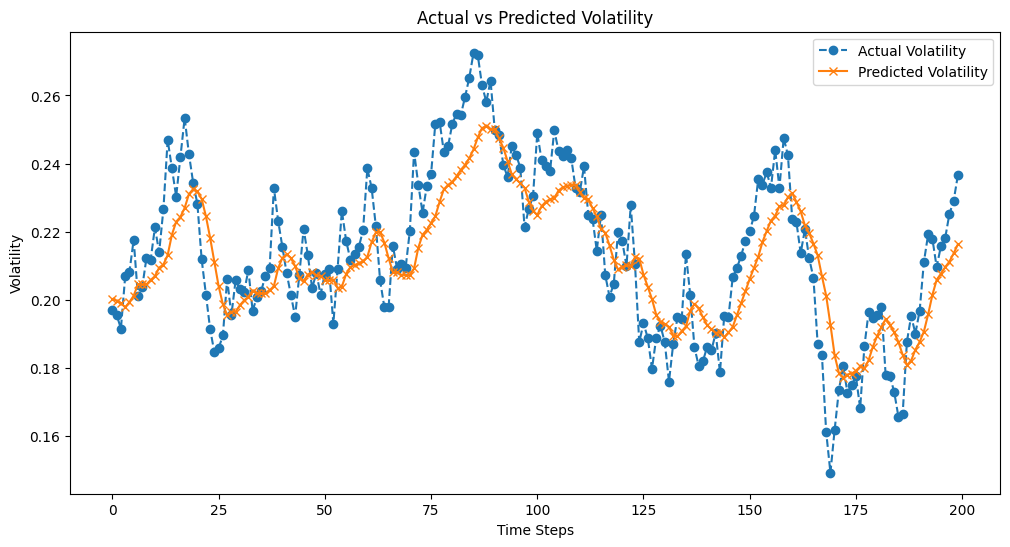

In [7]:
# Set random seed for reproducibility
keras.utils.set_random_seed(42)

# Generate a synthetic but persistent volatility time series
n_obs = 1010

volatility = np.zeros(n_obs)
volatility[0] = 0.20

for t in range(1, n_obs):
    volatility[t] = (
        0.02
        + 0.90 * volatility[t - 1]
        + np.random.normal(0, 0.01)
    )

    volatility[t] = max(volatility[t], 0.01)

# Create 10-period input sequences and next-period targets
lookback = 10

X = []
y = []

for i in range(len(volatility) - lookback):
    X.append(volatility[i:i + lookback])
    y.append(volatility[i + lookback])

X = np.array(X).reshape(-1, lookback, 1)
y = np.array(y).reshape(-1, 1)

# Chronological train/test split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

# Building the LSTM model
model = Sequential()
model.add(Input(shape=(lookback, 1)))
model.add(LSTM(50))
model.add(Dense(1))

# Compiling the model
model.compile(optimizer='adam', loss='mse')

# Training the model
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=20,
    validation_split=0.2,
    shuffle=False
)

# Predicting future volatility
predictions = model.predict(X_test)

# Plotting the actual vs predicted volatility
plt.figure(figsize=(12, 6))

plt.plot(
    y_test,
    label="Actual Volatility",
    linestyle='--',
    marker='o'
)

plt.plot(
    predictions,
    label="Predicted Volatility",
    linestyle='-',
    marker='x'
)

plt.title("Actual vs Predicted Volatility")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.show()